In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "monospace"

_ROOT = Path.cwd().parent
_CORE = _ROOT / "core"
_DATA = _ROOT / "data"
EXPERT = _DATA / "expert.npz"
TESTS = _ROOT / "tests"

testIDs: list[str] = []

for test in os.listdir(TESTS):
    if test.isdigit():
        testIDs.append(int(test))

TEST = TESTS / f"{max(testIDs):02d}"

print(f"NumPy Version: {np.__version__}")

NumPy Version: 2.4.4


In [2]:
print(f"Data Path: {EXPERT}")
dExpert = np.load(EXPERT)

print("Expert Data Keys:", dExpert.files)

Data Path: /home/abhans/Projects/acraft/data/expert.npz
Expert Data Keys: ['trajectories']


# Expert Data
Expert data consists of data in shape `(Number of waypoints, Steps per waypoint, The state and action vector for each step)`

In [3]:
print(f"Shape of the expert data: {dExpert["trajectories"].shape}")

Shape of the expert data: (4000, 1000, 10)


In [4]:
numOfTraj, stepsPerTraj, params = dExpert["trajectories"].shape

print(
    f"Number of Trajectories: {numOfTraj}",
    f"Steps per Trajectory: {stepsPerTraj}",
    f"Parameters per Step: {params}",
    sep="\n",
)

Number of Trajectories: 4000
Steps per Trajectory: 1000
Parameters per Step: 10


# Plotting the Parameters

For a single chosen trajectory, we can plot the action and state vectors

In [5]:
trajIdx = np.random.randint(numOfTraj)
traj = dExpert["trajectories"][trajIdx]

timeSteps = np.arange(stepsPerTraj)
print(f"Data from trajectory: {trajIdx}")

Data from trajectory: 2186


In [6]:
# Name the parameters
#  state = np.array([x, y, vx, vy, theta, omega, windX, windY], dtype=np.float32)
#  action = np.array([lThrust, rThrust], dtype=np.float32)
x, y, vx, vy, theta, omega, windX, windY = traj[:, :8].T
lThrust, rThrust = traj[:, 8:].T

print(f"Actions | RThrust: \n{rThrust}, LThrust: {lThrust}")

# Compute wind magnitude
windMag = np.hypot(windX, windY)

Actions | RThrust: 
[0.23893495 0.61894786 0.6464791  0.63217264 0.6477666  0.66286707
 0.63235456 0.6335873  0.6140436  0.63239163 0.5976011  0.59877676
 0.5898973  0.58918226 0.59125036 0.57589966 0.5130839  0.4596792
 0.5959706  0.58981395 0.58272564 0.563271   0.5592627  0.5653501
 0.5839032  0.5723467  0.58586985 0.54869664 0.5667547  0.552656
 0.5415473  0.5397923  0.5438621  0.532756   0.51752293 0.5246862
 0.516969   0.5104603  0.5123498  0.5100028  0.52544415 0.49682802
 0.50876194 0.4853636  0.49912736 0.48885927 0.5081865  0.48195034
 0.47653413 0.50665766 0.49324998 0.4899042  0.46960446 0.47521415
 0.49365652 0.47656143 0.48222664 0.46792427 0.47207233 0.46654174
 0.47810104 0.4603221  0.45671487 0.48006898 0.4612713  0.46129152
 0.46036452 0.4832387  0.47405303 0.47953814 0.46358317 0.47524709
 0.48640886 0.46895656 0.470296   0.46091828 0.47611353 0.46851015
 0.44720012 0.44938642 0.4573801  0.45202515 0.47053802 0.4650159
 0.4501124  0.4662723  0.4568592  0.45021322 0.4

In [7]:
OCHRE: str   = "#BBA358"

SEAFOAM: str = "#245C69"
AQUA: str    = "#689D6A"

RED: str     = "#FB4934"
BLUE: str    = "#458588"

BLACK: str   = "#282828"
ORANGE: str  = "#FE8019"

# Wind Visualization
SAGE: str    = "#4E7D5D"

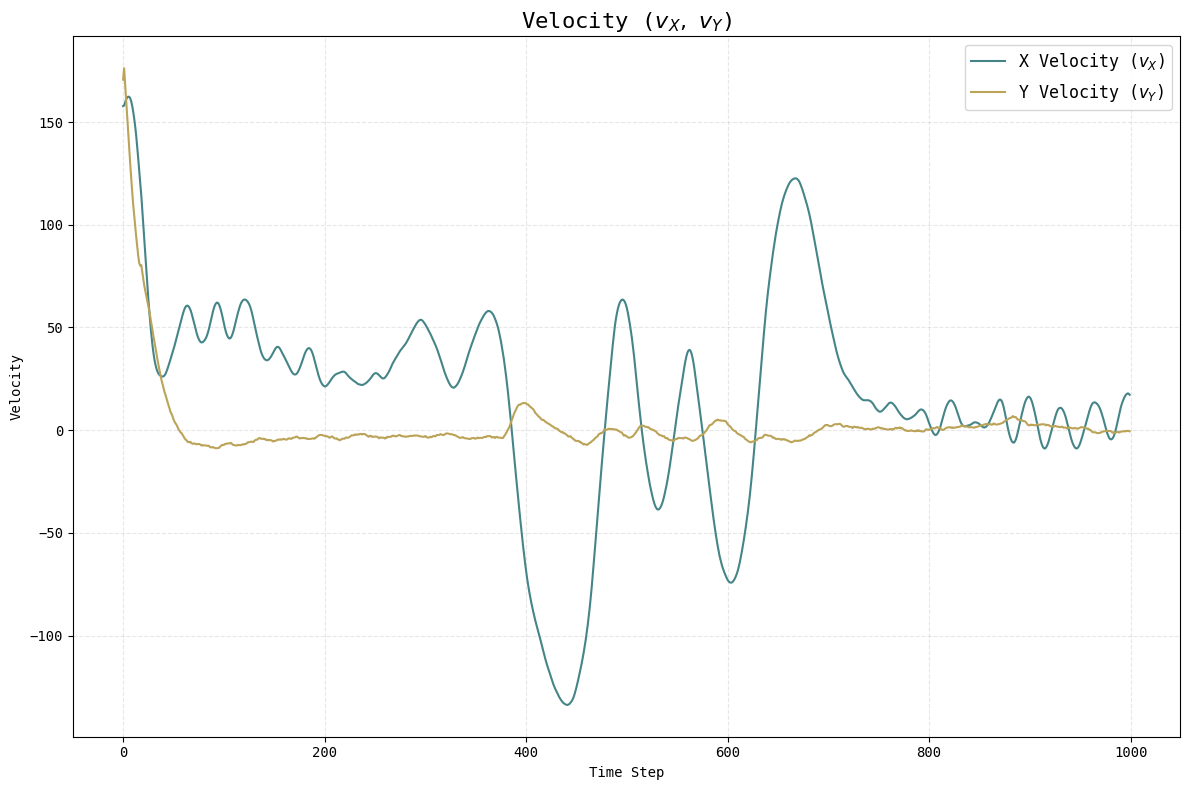

In [8]:
plt.figure(figsize=(12, 8))
# ------------ Velocity Plot ------------ 
plt.plot(timeSteps, vx, label=r"X Velocity ($v_X$)", color=BLUE)
plt.plot(timeSteps, vy, label=r"Y Velocity ($v_Y$)", color=OCHRE)
plt.title(r"Velocity ($v_X,\ v_Y$)", fontsize=16)
plt.xlabel("Time Step")
plt.ylabel("Velocity")
plt.legend(loc="upper right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

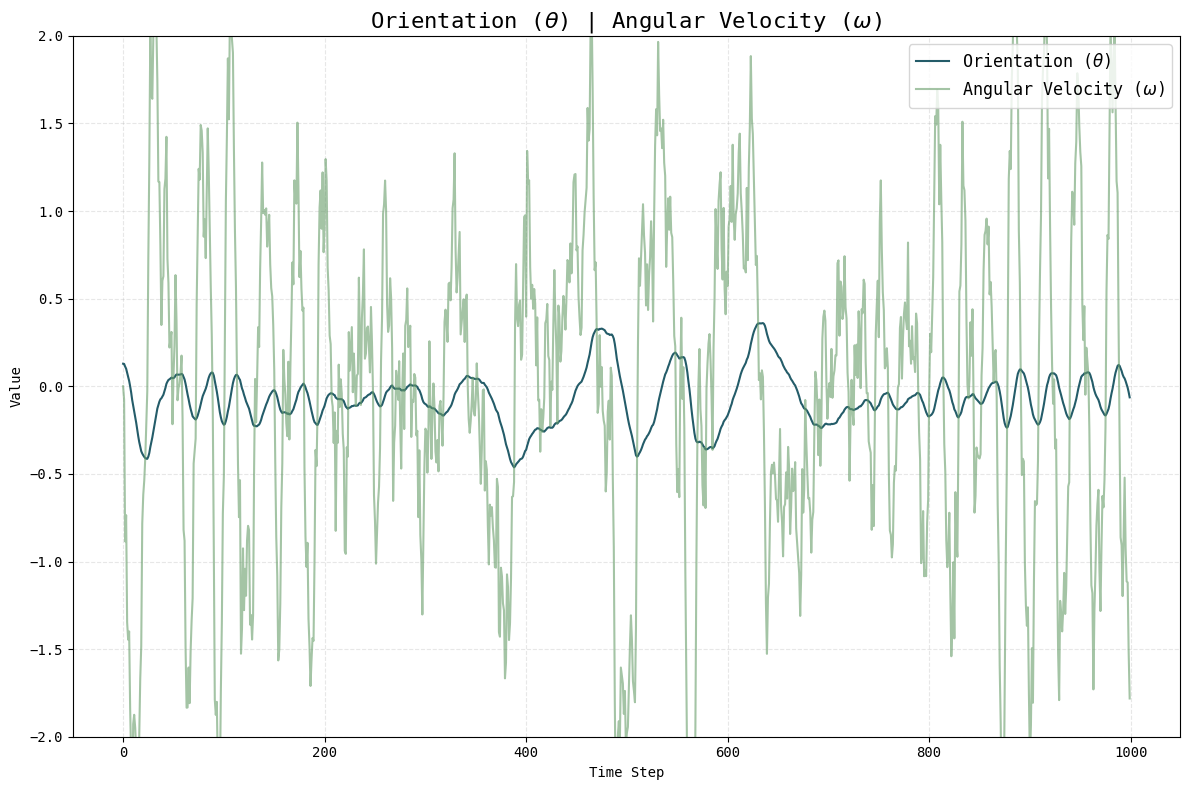

In [9]:
plt.figure(figsize=(12, 8))
# ------------ Orientation & Angular Velocity Plot ------------
plt.plot(timeSteps, theta, label=r"Orientation ($\theta$)", color=SEAFOAM)
plt.plot(timeSteps, omega, label=r"Angular Velocity ($\omega$)", alpha=.6, color=AQUA)
plt.title(r"Orientation ($\theta$) | Angular Velocity ($\omega$)", fontsize=16)
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.ylim(-2, 2)
plt.legend(loc="upper right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

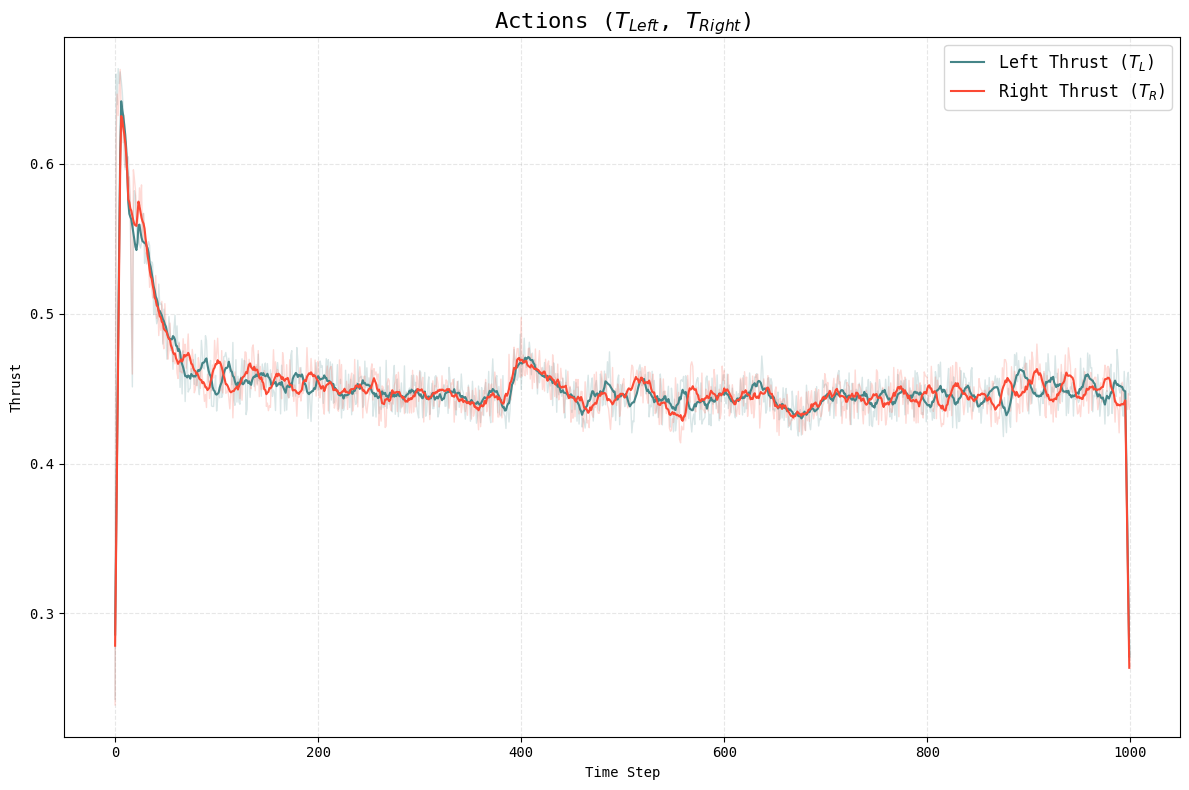

In [10]:
plt.figure(figsize=(12, 8))
sWindow: int = 10
kernel: np.ndarray = np.ones(sWindow) / sWindow
# ------------ Actions (Thrust) Plot ------------
plt.plot(timeSteps, lThrust, alpha=0.2, linewidth=1, color=BLUE)
plt.plot(timeSteps, rThrust, alpha=0.2, linewidth=1, color=RED)

plt.plot(
    timeSteps,
    np.convolve(lThrust, kernel, mode="same"),
    label=r"Left Thrust ($T_{L}$)", linewidth=1.5, color=BLUE
)
plt.plot(
    timeSteps,
    np.convolve(rThrust, kernel, mode="same"),
    label=r"Right Thrust ($T_{R}$)", linewidth=1.5, color=RED
)

plt.title(r"Actions ($T_{Left}$, $T_{Right}$)", fontsize=16)
plt.xlabel("Time Step")
plt.ylabel("Thrust")
plt.legend(loc="upper right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Telemetry Data

Telemetry data is collected to save the first `10` episodes, over `1000` timesteps with values from states and actions.

In [11]:
dTelemetry = pd.read_csv(TEST / "telemetry.csv")
dTelemetry.head()

,Episode,Step,X,Y,Distance,Vx,Vy,Theta,Omega,Wx,Wy,LeftTh,RightTh,Reward
0,1,0,690.60535,398.22122,147.01904,35.740677,123.441890,0.080742,0.337469,99.594826,37.415554,0.659408,0.676452,-1.451730
1,1,1,691.25720,400.15560,147.83823,39.109730,116.064000,0.092204,0.687727,100.047320,36.449398,0.649111,0.666986,-1.373697
2,1,2,691.96650,401.96980,148.55664,42.557575,108.851530,0.097311,0.306414,100.472145,35.530556,0.664178,0.645296,-1.146689
3,1,3,692.73360,403.66492,149.17271,46.025460,101.707954,0.099357,0.122739,100.872760,34.658653,0.658714,0.649605,-0.956607
4,1,4,693.55670,405.23676,149.68283,49.386120,94.310880,0.094150,-0.312419,101.252090,33.833534,0.673893,0.651983,-0.835191


In [12]:
print(f"Columns: {dTelemetry.columns}")

Columns: Index(['Episode', 'Step', 'X', 'Y', 'Distance', 'Vx', 'Vy', 'Theta', 'Omega',
       'Wx', 'Wy', 'LeftTh', 'RightTh', 'Reward'],
      dtype='str')


In [13]:
dTelemetry.drop(columns=["X", "Y", "Theta", "Omega"], inplace=True)
print(f"Columns to be used: {dTelemetry.columns}")

Columns to be used: Index(['Episode', 'Step', 'Distance', 'Vx', 'Vy', 'Wx', 'Wy', 'LeftTh',
       'RightTh', 'Reward'],
      dtype='str')


In [14]:
EPISODE: int = 2
dEpisode = dTelemetry[dTelemetry["Episode"] == EPISODE]
print(f"Data for Episode: {EPISODE}")
dEpisode.head()

Data for Episode: 2


,Episode,Step,Distance,Vx,Vy,Wx,Wy,LeftTh,RightTh,Reward
1000,2,0,38.673107,137.59160,32.320793,55.918080,9.621210,0.560709,0.535024,0.058681
1001,2,1,38.540794,140.15787,29.427350,56.142650,9.167515,0.554057,0.516444,-0.156337
1002,2,2,38.497670,142.15541,26.214226,56.332268,8.710620,0.562269,0.523708,-0.375022
1003,2,3,38.551147,143.51454,23.100676,56.485065,8.253983,0.540606,0.536467,-0.499058
1004,2,4,38.708256,144.13097,20.242683,56.601400,7.800021,0.539857,0.519765,-0.726365


In [15]:
dEpisode["Wmag"] = np.hypot(dEpisode["Wx"], dEpisode["Wy"])
dEpisode["Wang"] = np.degrees(np.arctan2(dEpisode["Wy"], dEpisode["Wx"]))

dEpisode["Wang"] = (dEpisode["Wang"] + 360.0) % 360.0
dEpisode.drop(columns=["Wx", "Wy"], inplace=True)
print(f"Data for Episode: {dEpisode.columns}")

Data for Episode: Index(['Episode', 'Step', 'Distance', 'Vx', 'Vy', 'LeftTh', 'RightTh',
       'Reward', 'Wmag', 'Wang'],
      dtype='str')


## Distance to Target

The distance to target could be used to provide understanding of if the waypoint is reached.

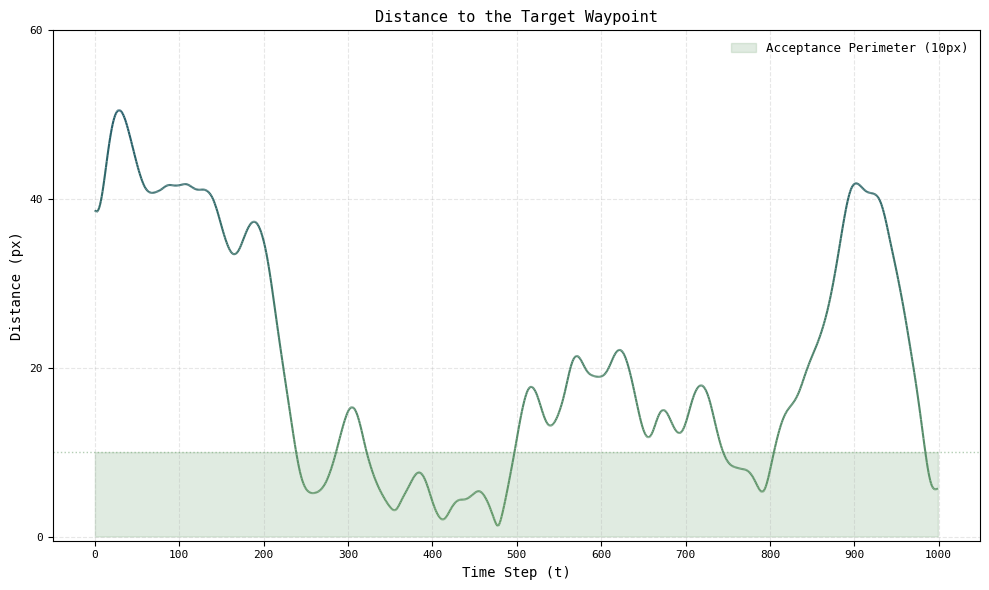

In [16]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

steps: pd.Series = dEpisode["Step"]
distance = dEpisode["Distance"].values

plt.figure(figsize=(10, 6))

# ------------ PLOT: Acceptance Perimeter (10px) ------------
plt.fill_between(
    steps,
    0, 10,
    color=AQUA,
    alpha=0.2,
    label="Acceptance Perimeter (10px)"
)
plt.axhline(y=10, color=AQUA, linestyle=":", alpha=0.5, linewidth=1)

# ------------ PLOT: Distance (Gradient) ------------
cmap = LinearSegmentedColormap.from_list(
    "DistanceColormap", 
    [AQUA, SEAFOAM]
)

points = np.array([steps, distance]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(vmin=0, vmax=distance.max())

lc = LineCollection(segments, cmap=cmap, norm=norm, linewidths=1.5)
lc.set_array(distance)
plt.gca().add_collection(lc)

plt.title("Distance to the Target Waypoint", fontsize=11)
plt.xlabel("Time Step (t)", fontsize=10)
plt.ylabel("Distance (px)", fontsize=10)

plt.xticks(np.arange(0, steps.max() + 100, 100), fontsize=8)
plt.yticks(np.arange(-0, dEpisode["Distance"].max() + 20, 20), fontsize=8)

plt.legend(loc="upper right", fontsize=9, shadow=False, frameon=False)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Active Speed For Both Axis

The active speed for both the axis could help visualize the changes in speed.

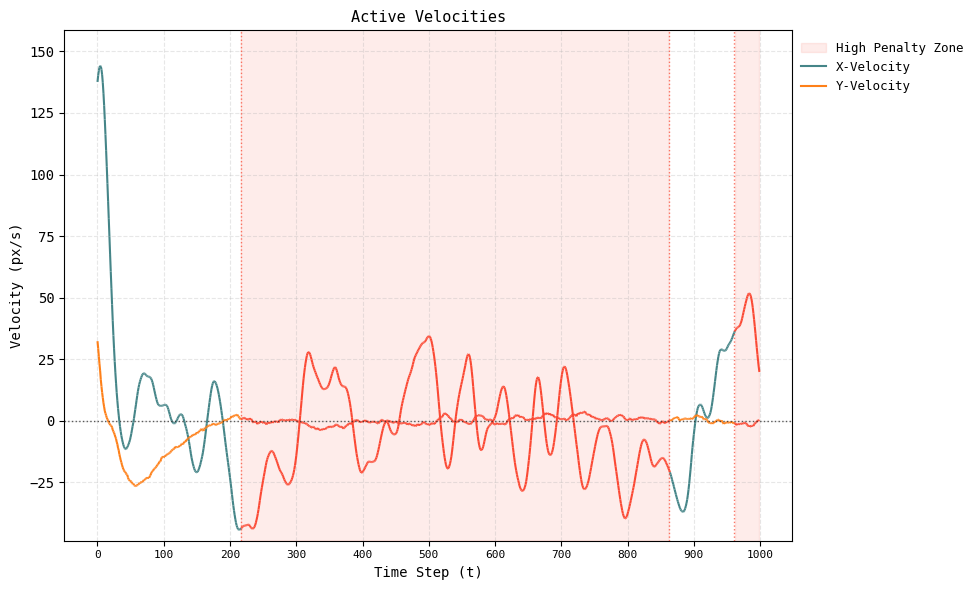

In [17]:
from matplotlib.colors import ListedColormap

steps = dEpisode["Step"].values
vX = dEpisode["Vx"].values
vY = dEpisode["Vy"].values
distance = dEpisode["Distance"].values

# Create a binary penalty mask: 
#   1 if inside penalty zone, 0 if outside
maskPenalty = (distance < 25.0).astype(int)

plt.figure(figsize=(10, 6))

def createMaskedLine(x, y, mask, colorNormal, colorPenalty=RED):
    # Reshape line into segments
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    cmap = ListedColormap([colorNormal, colorPenalty])
    lc = LineCollection(segments, cmap=cmap, linewidths=1.5)
    lc.set_array(mask[:-1])

    return lc

# Create and add the dynamically colored velocity lines
vXlc = createMaskedLine(steps, vX, maskPenalty, colorNormal=BLUE)
vYlc = createMaskedLine(steps, vY, maskPenalty, colorNormal=ORANGE)

plt.gca().add_collection(vXlc)
plt.gca().add_collection(vYlc)

minY = min(vX.min(), vY.min()) * 1.1
maxY = max(vX.max(), vY.max()) * 1.1

plt.fill_between(
    steps,
    minY, 
    maxY,
    where=(distance < 25.0), 
    color=RED, 
    alpha=0.1,
    label="High Penalty Zone"
)

transitions = np.diff(maskPenalty)
transition_indices = np.where(transitions != 0)[0]

# Draw a vertical dashed line at each boundary transition point
for idx in transition_indices:
    plt.axvline(
        x=steps[idx], 
        color=RED, 
        linestyle=":", 
        linewidth=1, 
        alpha=0.75
    )

plt.axhline(0, color=BLACK, linewidth=1, alpha=0.75, linestyle=":")

# ---- Layout and Labeling ----
plt.title("Active Velocities", fontsize=11)
plt.xlabel("Time Step (t)", fontsize=10)
plt.ylabel("Velocity (px/s)", fontsize=10)

plt.ylim(minY, maxY)

plt.xticks(np.arange(0, steps.max() + 100, 100), fontsize=8)

# Dummy plots to feed clean, non-fragmented entries to the legend box
plt.plot([], [], color=BLUE, label="X-Velocity")
plt.plot([], [], color=ORANGE, label="Y-Velocity")
plt.plot([], [], color=RED)

plt.legend(
    loc="upper right", fontsize=9,
    shadow=False, frameon=False,
    bbox_to_anchor=(1.25, 1.0)
)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Left/Right Thrust Levels

Thrust levels for both left and right thrusters could be used to visualize the action at a current timestamp.

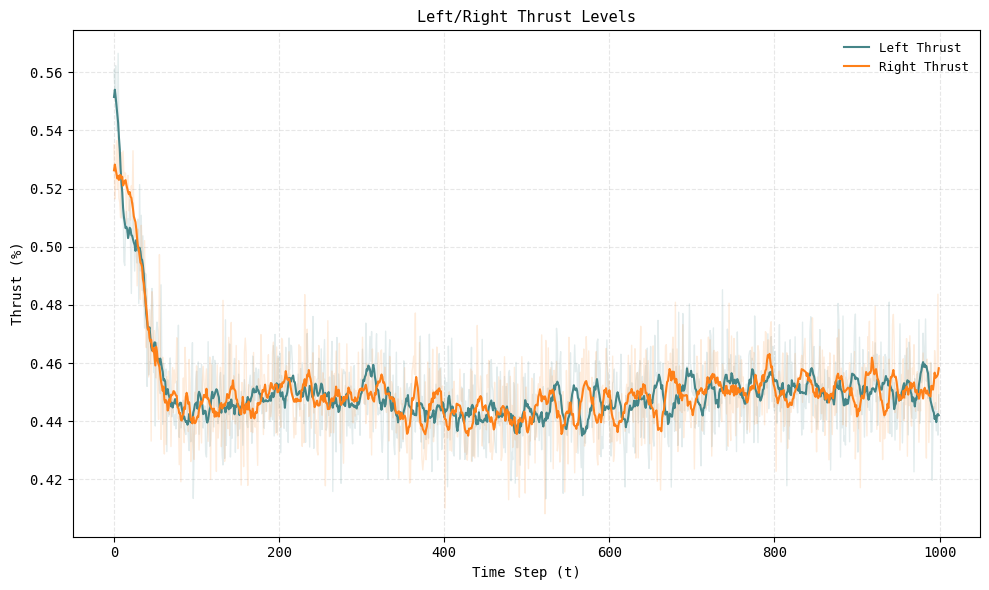

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

timeSteps = dEpisode["Step"].values
lThrust = dEpisode["LeftTh"].values
rThrust = dEpisode["RightTh"].values

# Calculate Net Differential Thrust (Left - Right)
diffThrust = lThrust - rThrust

# Moving Average Smoothing Window
sWindow = 10
kernel = np.ones(sWindow) / sWindow

lThrustSmoothed = pd.Series(lThrust).rolling(window=sWindow, center=True, min_periods=1).mean()
rThrustSmoothed = pd.Series(rThrust).rolling(window=sWindow, center=True, min_periods=1).mean()
diffThrustSmoothed = pd.Series(diffThrust).rolling(window=sWindow, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 6))

# High-frequency raw inputs
ax.plot(timeSteps, lThrust, alpha=0.15, linewidth=1, color=BLUE)
ax.plot(timeSteps, rThrust, alpha=0.15, linewidth=1, color=ORANGE)

# Macroscopic control trend (Smoothed)
ax.plot(timeSteps, lThrustSmoothed, label="Left Thrust", linewidth=1.5, color=BLUE)
ax.plot(timeSteps, rThrustSmoothed, label="Right Thrust", linewidth=1.5, color=ORANGE)

ax.set_xlabel("Time Step (t)", fontsize=10)
ax.set_ylabel("Thrust (%)", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.title("Left/Right Thrust Levels", fontsize=11)

plt.legend(
    loc="upper right", fontsize=9,
    shadow=False, frameon=False
)

plt.tight_layout()
plt.show()

## Reward

The reward for the episode could be used to visualize the "success"

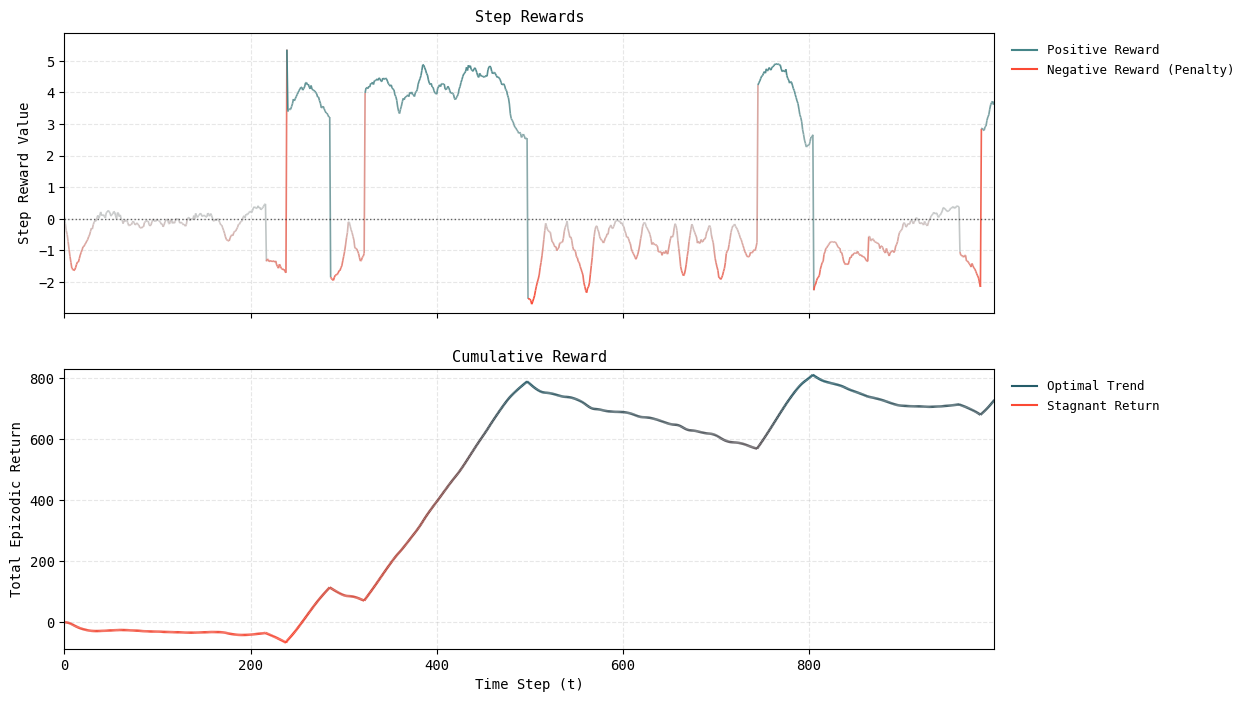

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

timeSteps = dEpisode["Step"].values
rewards = dEpisode["Reward"].values

# Cumulative Reward (Return)
rewardCumulative = np.cumsum(rewards)

# Identify Waypoint Hit Events for discrete markers
if "Waypoint_Reached" in dEpisode.columns:
    waypointHits = dEpisode.loc[dEpisode["Waypoint_Reached"], "Step"].values
else:
    waypointHits = dEpisode[rewards >= 2.0]["Step"].values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ------------ CMAP: Colormaps for rewards
cmapStep = LinearSegmentedColormap.from_list("StepCmap", [RED, "#CCCCCC", BLUE])
cmapCumulative = LinearSegmentedColormap.from_list("CumulativeCmap", [RED, SEAFOAM])

# ------------ PLOT: Step Reward Profile
points_step = np.array([timeSteps, rewards]).T.reshape(-1, 1, 2)
segments_step = np.concatenate([points_step[:-1], points_step[1:]], axis=1)

rewardsMin = min(rewards.min(), -0.1)
rewardsMax = max(rewards.max(), 0.1)

normStep = TwoSlopeNorm(vcenter=0.0, vmin=rewardsMin, vmax=rewardsMax)

lcStep = LineCollection(segments_step, cmap=cmapStep, norm=normStep, linewidths=1.2)
lcStep.set_array(rewards)
ax1.add_collection(lcStep)

ax1.axhline(0, color="black", linestyle=":", linewidth=1, alpha=0.6)

ax1.set_ylabel("Step Reward Value", fontsize=10)
ax1.set_title("Step Rewards", fontsize=11, pad=8)
ax1.set_ylim(rewardsMin * 1.1, rewardsMax * 1.1)
ax1.grid(True, linestyle="--", alpha=0.3)

# Dummy plots for legend formatting
ax1.plot([], [], color=BLUE, label="Positive Reward")
ax1.plot([], [], color=RED, label="Negative Reward (Penalty)")
ax1.legend(loc="upper right", fontsize=9, shadow=False, frameon=False, bbox_to_anchor=(1.27, 1.0))

# ------------ PLOT: Cumulative Reward
pointsCumulative = np.array([timeSteps, rewardCumulative]).T.reshape(-1, 1, 2)
segmentsCumulative = np.concatenate([pointsCumulative[:-1], pointsCumulative[1:]], axis=1)

# Standard normalization from lowest return to highest return
normCumulative = plt.Normalize(vmin=rewardCumulative.min(), vmax=rewardCumulative.max())

lcCumulative = LineCollection(segmentsCumulative, cmap=cmapCumulative, norm=normCumulative, linewidths=1.8)
lcCumulative.set_array(rewardCumulative)
ax2.add_collection(lcCumulative)

ax2.set_xlabel("Time Step (t)", fontsize=10)
ax2.set_ylabel("Total Epizodic Return", fontsize=10)
ax2.set_title("Cumulative Reward", fontsize=11, pad=5)
ax2.set_ylim(rewardCumulative.min() - 20, rewardCumulative.max() + 20)
ax2.grid(True, linestyle="--", alpha=0.3)

# Dummy plots for cumulative legend formatting
ax2.plot([], [], color=SEAFOAM, label="Optimal Trend")
ax2.plot([], [], color=RED, label="Stagnant Return")
ax2.legend(
    loc="upper right", fontsize=9,
    shadow=False, frameon=False,
    bbox_to_anchor=(1.19, 1.0)
)

plt.xlim(timeSteps.min(), timeSteps.max())
plt.show()

## Active Wind

The active wind magniute and its' direction could be used to visaulize the disturbance in the environment.

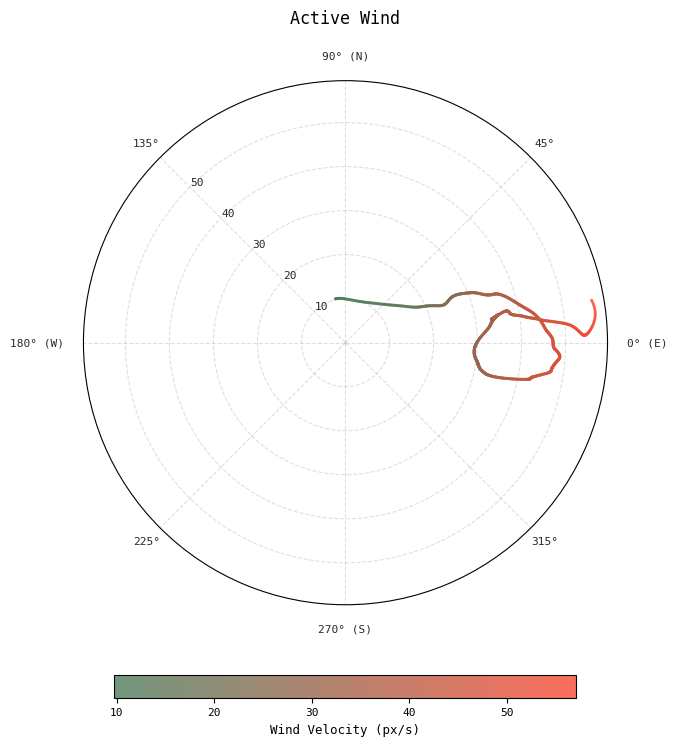

In [40]:
wMag = dEpisode["Wmag"].values
# Matplotlib's polar projection expects the angle input in radians
wAng = np.radians(dEpisode["Wang"].values)

# -------------------------------------------------------------------------
# Configuration & Figure Setup
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 8))
# Create an axes layout with polar projection
ax = plt.subplot(111, projection='polar')

# Custom Colormap: Calm/Low Wind = SAGE -> Severe Wind Velocity = RED
cmapWind = LinearSegmentedColormap.from_list("PolarWindCmap", [SAGE, RED])
normWind = plt.Normalize(
    vmin=max(wMag.min(), 0.0),
    vmax=max(wMag.max(), 1.0)
)

# ------------ PLOT: Polar Scatter of Wind Vectors
# theta = wAng (angular coordinates)
# r = wMag (radial distance from origin)
sc = ax.scatter(
    wAng, 
    wMag, 
    c=wMag,
    cmap=cmapWind, 
    norm=normWind, 
    s=5,
    alpha=0.8, 
    edgecolors="none",
    zorder=3
)

# ------------ Polar Axis Styling
ax.set_title("Active Wind", fontsize=12, pad=20)

ax.set_theta_zero_location("E")  # Set 0 degrees to the Right (East)
ax.set_theta_direction(1)        # 1 = Counter-clockwise, -1 = Clockwise

# Set clear labels for the angular orientations
ax.set_thetagrids(
    [0, 45, 90, 135, 180, 225, 270, 315],
    labels=["0° (E)", "45°", "90° (N)", "135°", "180° (W)", "225°", "270° (S)", "315°"],
    fontsize=8,
    color=BLACK,
)

# Configure the radial grid rings (Magnitude levels)
ax.set_rlabel_position(135)
ax.tick_params(axis='y', labelsize=8, colors=BLACK)
ax.grid(True, linestyle="--", alpha=0.4)

# Adjustment of angular label alignment
for label in ax.get_xticklabels():
    text = label.get_text()
    
    if "0° (E)" in text:
        label.set_horizontalalignment('left')
    elif "180° (W)" in text:
        label.set_horizontalalignment('right')
    elif "90° (N)" in text:
        label.set_verticalalignment('bottom')
    elif "270° (S)" in text:
        label.set_verticalalignment('top')

# ------------ CBAR: Magnitude Context
cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.1, shrink=0.6)
cbar.set_label("Wind Velocity (px/s)", loc='center', fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()